import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

In [3]:
# Load the dataset
df = pd.read_csv("cicids2017_cleaned.csv")

# Basic shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 2520751
Columns: 53


In [4]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Full structural check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2520751 entries, 0 to 2520750
Data columns (total 53 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Length of Fwd Packets  int64  
 4   Fwd Packet Length Max        int64  
 5   Fwd Packet Length Min        int64  
 6   Fwd Packet Length Mean       float64
 7   Fwd Packet Length Std        float64
 8   Bwd Packet Length Max        int64  
 9   Bwd Packet Length Min        int64  
 10  Bwd Packet Length Mean       float64
 11  Bwd Packet Length Std        float64
 12  Flow Bytes/s                 float64
 13  Flow Packets/s               float64
 14  Flow IAT Mean                float64
 15  Flow IAT Std                 float64
 16  Flow IAT Max                 int64  
 17  Flow IAT Min                 int64  
 18  Fwd IAT Total                int64  
 19  Fwd IAT Mea

In [6]:
df["Attack Type"].value_counts()

Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64

In [7]:
df["Attack Type"].value_counts(normalize=True) * 100

Attack Type
Normal Traffic    83.112414
DoS                7.686003
DDoS               5.078407
Port Scanning      3.597896
Brute Force        0.362987
Web Attacks        0.085014
Bots               0.077279
Name: proportion, dtype: float64

In [8]:
# Missing values per column
df.isnull().sum().sort_values(ascending=False).head(10)

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Length of Fwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
dtype: int64

In [9]:
# Infinite values per numeric column
np.isinf(df.select_dtypes(include=np.number)).sum().sort_values(ascending=False).head(10)

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Length of Fwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(161)

In [11]:
df.nunique().sort_values().head(10)

ACK Flag Count              2
FIN Flag Count              2
PSH Flag Count              2
Attack Type                 7
min_seg_size_forward       28
Min Packet Length         215
Fwd Packet Length Min     384
Bwd Packet Length Min     583
act_data_pkt_fwd         1083
Total Fwd Packets        1413
dtype: int64

In [12]:
df.describe().T[["min", "max", "mean", "std"]]

,min,max,mean,std
Destination Port,0.000000e+00,6.553500e+04,8.690744e+03,1.901294e+04
Flow Duration,-1.300000e+01,1.200000e+08,1.659032e+07,3.523140e+07
Total Fwd Packets,1.000000e+00,2.197590e+05,1.025880e+01,7.943824e+02
Total Length of Fwd Packets,0.000000e+00,1.290000e+07,6.065243e+02,1.011595e+04
Fwd Packet Length Max,0.000000e+00,2.482000e+04,2.311993e+02,7.563122e+02
Fwd Packet Length Min,0.000000e+00,2.325000e+03,1.920377e+01,6.079887e+01
Fwd Packet Length Mean,0.000000e+00,5.940857e+03,6.350189e+01,1.955512e+02
Fwd Packet Length Std,0.000000e+00,7.125597e+03,7.732029e+01,2.968824e+02
Bwd Packet Length Max,0.000000e+00,1.953000e+04,9.749253e+02,2.038152e+03
Bwd Packet Length Min,0.000000e+00,2.896000e+03,4.316019e+01,7.088017e+01


In [13]:
# Count rows with negative values in columns where negative is impossible
suspect_cols = ["Flow Duration", "Flow Bytes/s", "Flow Packets/s",
                "Flow IAT Mean", "Flow IAT Max", "Flow IAT Min", "Fwd IAT Min",
                "Fwd Header Length", "Bwd Header Length", "min_seg_size_forward"]

for col in suspect_cols:
    n_neg = (df[col] < 0).sum()
    print(f"{col}: {n_neg} negative rows ({n_neg/len(df)*100:.4f}%)")

Flow Duration: 107 negative rows (0.0042%)
Flow Bytes/s: 78 negative rows (0.0031%)
Flow Packets/s: 107 negative rows (0.0042%)
Flow IAT Mean: 107 negative rows (0.0042%)
Flow IAT Max: 107 negative rows (0.0042%)
Flow IAT Min: 2875 negative rows (0.1141%)
Fwd IAT Min: 17 negative rows (0.0007%)
Fwd Header Length: 35 negative rows (0.0014%)
Bwd Header Length: 22 negative rows (0.0009%)
min_seg_size_forward: 35 negative rows (0.0014%)


In [14]:
np.isinf(df.select_dtypes(include=np.number)).sum().sort_values(ascending=False).head(10)

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Length of Fwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
dtype: int64

In [5]:
# --- Cleaning pipeline (Guide Section 8) ---

rows_before = df.shape[0]

# 1. Replace infinities with NaN so they get handled by imputation below
df = df.replace([np.inf, -np.inf], np.nan)

# 2. Remove rows with physically impossible negative values
#    (duration, rates, and inter-arrival times cannot be negative;
#     header-length/seg-size negatives here are corrupted, not meaningful)
suspect_cols = ["Flow Duration", "Flow Bytes/s", "Flow Packets/s",
                "Flow IAT Mean", "Flow IAT Max", "Flow IAT Min", "Fwd IAT Min",
                "Fwd Header Length", "Bwd Header Length", "min_seg_size_forward"]

for col in suspect_cols:
    df = df[df[col] >= 0]

# 3. Remove exact duplicate rows
df = df.drop_duplicates()

rows_after = df.shape[0]

print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning:  {rows_after}")
print(f"Rows removed:         {rows_before - rows_after} ({(rows_before-rows_after)/rows_before*100:.3f}%)")

Rows before cleaning: 2520751
Rows after cleaning:  2517681
Rows removed:         3070 (0.122%)


In [16]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
X = df.drop(columns=["Attack Type"])
y = df["Attack Type"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [6]:


print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

Train shape: (2014144, 52)
Test shape: (503537, 52)
Attack Type
Normal Traffic    1673739
DoS                154866
DDoS               102396
Port Scanning       72555
Brute Force          7315
Web Attacks          1714
Bots                 1559
Name: count, dtype: int64
Attack Type
Normal Traffic    418436
DoS                38716
DDoS               25599
Port Scanning      18139
Brute Force         1829
Web Attacks          429
Bots                 389
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    # "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [28]:
import os, joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

os.makedirs("saved_models", exist_ok=True)

results = []
confusion_matrices = {}
feature_importances = {}

models_to_run = {k: v for k, v in models.items() if k != "SVM"}

for name, model in models_to_run.items():
    filepath = f"saved_models/{name.replace(' ', '_')}.joblib"
    
    if os.path.exists(filepath):
        print(f"{name} already saved, loading from disk instead of retraining...")
        model = joblib.load(filepath)
        train_time, inference_time = None, None  # unknown for already-trained models
    else:
        print(f"Training {name}...")
        start = time.time()
        model.fit(X_train_scaled, y_train)
        train_time = time.time() - start
    
    start = time.time()
    y_pred = model.predict(X_test_scaled)
    inference_time = time.time() - start
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "Train Time (s)": train_time,
        "Inference Time (s)": inference_time
    })
    
    confusion_matrices[name] = confusion_matrix(y_test, y_pred, labels=model.classes_)
    
    if hasattr(model, "feature_importances_"):
        feature_importances[name] = pd.Series(
            model.feature_importances_, index=X.columns
        ).sort_values(ascending=False)
    elif hasattr(model, "coef_"):
        feature_importances[name] = pd.Series(
            np.abs(model.coef_).mean(axis=0), index=X.columns
        ).sort_values(ascending=False)
    
    if not os.path.exists(filepath):
        joblib.dump(model, filepath)
    del model
    
    print(f"  done ({name})")

results_df = pd.DataFrame(results)

Logistic Regression already saved, loading from disk instead of retraining...
  done (Logistic Regression)
Decision Tree already saved, loading from disk instead of retraining...
  done (Decision Tree)
Random Forest already saved, loading from disk instead of retraining...
  done (Random Forest)
Extra Trees already saved, loading from disk instead of retraining...
  done (Extra Trees)
Gradient Boosting already saved, loading from disk instead of retraining...
  done (Gradient Boosting)
KNN already saved, loading from disk instead of retraining...
  done (KNN)
Naive Bayes already saved, loading from disk instead of retraining...
  done (Naive Bayes)


In [29]:
results_df

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Train Time (s),Inference Time (s)
0,Logistic Regression,0.992982,0.762753,0.676014,0.692386,0.992133,None,0.170048
1,Decision Tree,0.998348,0.966206,0.962606,0.964375,0.998344,None,0.158529
2,Random Forest,0.998914,0.981084,0.952621,0.965299,0.998897,None,2.782694
3,Extra Trees,0.998149,0.971096,0.948060,0.958548,0.998132,None,2.882325
4,Gradient Boosting,0.997811,0.936909,0.950969,0.943515,0.997814,None,1.335600
5,KNN,0.997857,0.953667,0.932809,0.942145,0.997835,None,3025.763454
6,Naive Bayes,0.787807,0.634502,0.944591,0.661180,0.866605,None,2.151520


In [30]:
results_df.to_csv("results_df_baseline.csv", index=False)

In [31]:
import pickle
with open("confusion_matrices.pkl", "wb") as f:
    pickle.dump(confusion_matrices, f)
with open("feature_importances.pkl", "wb") as f:
    pickle.dump(feature_importances, f)

In [32]:
from sklearn.feature_selection import VarianceThreshold

vt_selector = VarianceThreshold(threshold=0.0)
vt_selector.fit(X_train)

vt_selected_features = X_train.columns[vt_selector.get_support()]
vt_removed_features = X_train.columns[~vt_selector.get_support()]

print("Features before:", X_train.shape[1])
print("Features after:", len(vt_selected_features))
print("Features removed:", len(vt_removed_features))
print("\nRemoved features:", list(vt_removed_features))

Features before: 52
Features after: 52
Features removed: 0

Removed features: []


In [33]:
from sklearn.feature_selection import mutual_info_classif
import time

start = time.time()
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_time = time.time() - start

mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print(f"Mutual Information computed in {mi_time:.2f}s")
print("\nTop 20 features by Mutual Information:")
print(mi_series.head(20))

Mutual Information computed in 1890.91s

Top 20 features by Mutual Information:
Average Packet Size            0.544892
Packet Length Mean             0.516758
Packet Length Std              0.511896
Packet Length Variance         0.510878
Bwd Packet Length Mean         0.461907
Subflow Fwd Bytes              0.448216
Total Length of Fwd Packets    0.448004
Init_Win_bytes_backward        0.436939
Bwd Packet Length Max          0.429988
Init_Win_bytes_forward         0.424917
Max Packet Length              0.416660
Fwd Packet Length Max          0.411614
Fwd IAT Max                    0.392221
Flow IAT Max                   0.381511
Destination Port               0.374534
Fwd IAT Total                  0.373687
Fwd Packet Length Mean         0.372870
Fwd Header Length              0.371769
Flow Duration                  0.364404
Flow Bytes/s                   0.357998
dtype: float64


In [34]:
from sklearn.feature_selection import SelectKBest, f_classif
import time

start = time.time()
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(X_train, y_train)
anova_time = time.time() - start

anova_series = pd.Series(anova_selector.scores_, index=X_train.columns).sort_values(ascending=False)

print(f"ANOVA F-test computed in {anova_time:.2f}s")
print("\nTop 20 features by ANOVA F-score:")
print(anova_series.head(20))

ANOVA F-test computed in 6.07s

Top 20 features by ANOVA F-score:
Bwd Packet Length Std     402807.690376
Bwd Packet Length Mean    395633.602590
Bwd Packet Length Max     380564.178598
Fwd IAT Std               376293.621888
Packet Length Std         331645.893224
Idle Mean                 329065.088745
Idle Min                  327218.425182
Idle Max                  312448.983633
Flow IAT Max              303456.021185
Fwd IAT Max               301593.515882
Max Packet Length         298261.374183
Average Packet Size       264417.973931
Packet Length Mean        260964.359111
Packet Length Variance    251771.380350
Flow IAT Std              189571.536501
Fwd IAT Total              93505.126561
Flow Duration              92894.435924
FIN Flag Count             83031.124674
Bwd IAT Std                49657.482736
Flow IAT Mean              46033.810385
dtype: float64


In [8]:
   print(X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape)

(2014144, 52) (503537, 52) (2014144,) (503537,)


In [9]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import os, json, time

os.makedirs("saved_metrics/anova_k", exist_ok=True)

k_values = [10, 20, 30, 50]

def get_models():
    # n_jobs=-1 on KNN this time -- parallelizes neighbor search across all cores
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
        "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
        "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
        "KNN": KNeighborsClassifier(n_jobs=-1),
        "Naive Bayes": GaussianNB()
    }

anova_k_results = []

for k in k_values:
    print(f"\n=== k = {k} ===")
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_k = selector.fit_transform(X_train_scaled, y_train)
    X_test_k = selector.transform(X_test_scaled)

    models_k = get_models()

    for name, model in models_k.items():
        cache_file = f"saved_metrics/anova_k/{name.replace(' ', '_')}_k{k}.json"

        if os.path.exists(cache_file):
            print(f"  {name} (k={k}): cached, skipping")
            with open(cache_file, "r") as f:
                anova_k_results.append(json.load(f))
            continue

        print(f"  {name} (k={k}): training + predicting...")
        start = time.time()
        model.fit(X_train_k, y_train)
        train_time = time.time() - start

        start = time.time()
        y_pred = model.predict(X_test_k)
        inference_time = time.time() - start

        metrics = {
            "k": k,
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1 (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
            "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "Train Time (s)": train_time,
            "Inference Time (s)": inference_time
        }
        anova_k_results.append(metrics)

        with open(cache_file, "w") as f:
            json.dump(metrics, f)

        print(f"    done ({name}, k={k}) - train {train_time:.1f}s, infer {inference_time:.1f}s")

anova_k_df = pd.DataFrame(anova_k_results)
anova_k_df.to_csv("results_df_anova_k_comparison.csv", index=False)
print("\nAll done. Saved to results_df_anova_k_comparison.csv")


=== k = 10 ===
  Logistic Regression (k=10): training + predicting...
    done (Logistic Regression, k=10) - train 238.6s, infer 0.1s
  Decision Tree (k=10): training + predicting...
    done (Decision Tree, k=10) - train 41.6s, infer 0.1s
  Random Forest (k=10): training + predicting...
    done (Random Forest, k=10) - train 223.4s, infer 1.8s
  Extra Trees (k=10): training + predicting...
    done (Extra Trees, k=10) - train 149.9s, infer 3.5s
  Gradient Boosting (k=10): training + predicting...
    done (Gradient Boosting, k=10) - train 23.0s, infer 1.2s
  KNN (k=10): training + predicting...
    done (KNN, k=10) - train 20.3s, infer 77.3s
  Naive Bayes (k=10): training + predicting...
    done (Naive Bayes, k=10) - train 5.3s, infer 0.5s

=== k = 20 ===
  Logistic Regression (k=20): training + predicting...
    done (Logistic Regression, k=20) - train 511.9s, infer 0.1s
  Decision Tree (k=20): training + predicting...
    done (Decision Tree, k=20) - train 93.4s, infer 0.1s
  Rand

In [10]:
anova_k_df.sort_values(["Model", "k"]).reset_index(drop=True)

,k,Model,Accuracy,F1 (macro),F1 (weighted),Precision (macro),Recall (macro),Train Time (s),Inference Time (s)
0,10,Decision Tree,0.995704,0.910320,0.995628,0.941441,0.888413,41.557876,0.102297
1,20,Decision Tree,0.997021,0.915224,0.996949,0.944717,0.895143,93.370115,0.111852
2,30,Decision Tree,0.997327,0.924423,0.997317,0.927092,0.921860,127.310164,0.118846
3,50,Decision Tree,0.998340,0.964179,0.998338,0.964676,0.963697,278.720310,0.185502
4,10,Extra Trees,0.996560,0.920889,0.996478,0.961138,0.895970,149.893033,3.523604
5,20,Extra Trees,0.997345,0.922798,0.997265,0.961805,0.898452,149.422144,2.709056
6,30,Extra Trees,0.997617,0.925699,0.997601,0.931843,0.919920,149.603066,2.605776
7,50,Extra Trees,0.998189,0.958806,0.998173,0.969793,0.949558,202.814747,2.895588
8,10,Gradient Boosting,0.988098,0.792231,0.988280,0.813595,0.785874,22.970939,1.189423
9,20,Gradient Boosting,0.993724,0.795746,0.993439,0.814004,0.785517,20.140390,1.294069


In [10]:
print(X_train.shape, X_test.shape, X_train_scaled.shape, X_test_scaled.shape)

(2014144, 52) (503537, 52) (2014144, 52) (503537, 52)


In [11]:
from sklearn.feature_selection import mutual_info_classif
import time

start = time.time()
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_time = time.time() - start

mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# Save immediately — before printing anything, before anything else can go wrong
mi_series.to_csv("mi_series.csv", header=["MI_Score"])

print(f"Mutual Information computed in {mi_time:.2f}s")
print("Saved to mi_series.csv")
print("\nTop 20 features by Mutual Information:")
print(mi_series.head(20))

Mutual Information computed in 1867.21s
Saved to mi_series.csv

Top 20 features by Mutual Information:
Average Packet Size            0.544892
Packet Length Mean             0.516758
Packet Length Std              0.511896
Packet Length Variance         0.510878
Bwd Packet Length Mean         0.461907
Subflow Fwd Bytes              0.448216
Total Length of Fwd Packets    0.448004
Init_Win_bytes_backward        0.436939
Bwd Packet Length Max          0.429988
Init_Win_bytes_forward         0.424917
Max Packet Length              0.416660
Fwd Packet Length Max          0.411614
Fwd IAT Max                    0.392221
Flow IAT Max                   0.381511
Destination Port               0.374534
Fwd IAT Total                  0.373687
Fwd Packet Length Mean         0.372870
Fwd Header Length              0.371769
Flow Duration                  0.364404
Flow Bytes/s                   0.357998
dtype: float64


In [12]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
import time

rfe_estimator = DecisionTreeClassifier(random_state=42)
rfe_selector = RFE(estimator=rfe_estimator, n_features_to_select=20, step=2)

start = time.time()
rfe_selector.fit(X_train_scaled, y_train)
rfe_time = time.time() - start

rfe_ranking = pd.Series(rfe_selector.ranking_, index=X_train.columns).sort_values()
rfe_selected_features = X_train.columns[rfe_selector.support_]

# Save immediately
rfe_ranking.to_csv("rfe_ranking.csv", header=["RFE_Rank"])
pd.Series(rfe_selected_features).to_csv("rfe_selected_features.csv", index=False, header=["Feature"])

print(f"RFE computed in {rfe_time:.2f}s")
print("Saved to rfe_ranking.csv and rfe_selected_features.csv")
print(f"\nSelected {len(rfe_selected_features)} features:")
print(list(rfe_selected_features))

RFE computed in 3108.95s
Saved to rfe_ranking.csv and rfe_selected_features.csv

Selected 20 features:
['Destination Port', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Min', 'Fwd IAT Min', 'Bwd IAT Std', 'Fwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Std', 'PSH Flag Count', 'Average Packet Size', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forward', 'Idle Min']


In [13]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif

# --- Load MI results (already saved) ---
mi_series = pd.read_csv("mi_series.csv", index_col=0)["MI_Score"]
mi_top20 = set(mi_series.sort_values(ascending=False).head(20).index)

# --- Recompute ANOVA (fast, ~6s, not saved earlier so redo + save now) ---
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(X_train, y_train)
anova_series = pd.Series(anova_selector.scores_, index=X_train.columns).sort_values(ascending=False)
anova_series.to_csv("anova_series.csv", header=["ANOVA_F_Score"])  # save this time
anova_top20 = set(anova_series.head(20).index)

# --- Load RFE selected features (already saved) ---
rfe_selected = set(pd.read_csv("rfe_selected_features.csv")["Feature"])

# --- Consensus: intersection of all three ---
consensus_features = mi_top20 & anova_top20 & rfe_selected
consensus_features = sorted(consensus_features)

print(f"MI top 20:     {len(mi_top20)} features")
print(f"ANOVA top 20:  {len(anova_top20)} features")
print(f"RFE selected:  {len(rfe_selected)} features")
print(f"\nConsensus (intersection of all 3): {len(consensus_features)} features")
print(consensus_features)

# Save the consensus set
pd.Series(consensus_features).to_csv("consensus_features.csv", index=False, header=["Feature"])
print("\nSaved to consensus_features.csv")

MI top 20:     20 features
ANOVA top 20:  20 features
RFE selected:  20 features

Consensus (intersection of all 3): 3 features
['Average Packet Size', 'Bwd Packet Length Mean', 'Packet Length Std']

Saved to consensus_features.csv


In [14]:
from collections import Counter

# Count how many of the 3 methods selected each feature
all_selections = list(mi_top20) + list(anova_top20) + list(rfe_selected)
vote_counts = Counter(all_selections)

# Majority vote: appears in at least 2 of 3 methods
majority_features = sorted([f for f, count in vote_counts.items() if count >= 2])

print(f"Features appearing in >=2 of 3 methods: {len(majority_features)}")
print(majority_features)

# Also show the pairwise overlaps for your report
print(f"\nMI ∩ ANOVA:  {len(mi_top20 & anova_top20)} — {sorted(mi_top20 & anova_top20)}")
print(f"MI ∩ RFE:    {len(mi_top20 & rfe_selected)} — {sorted(mi_top20 & rfe_selected)}")
print(f"ANOVA ∩ RFE: {len(anova_top20 & rfe_selected)} — {sorted(anova_top20 & rfe_selected)}")

pd.Series(majority_features).to_csv("majority_vote_features.csv", index=False, header=["Feature"])
print("\nSaved to majority_vote_features.csv")

Features appearing in >=2 of 3 methods: 22
['Average Packet Size', 'Bwd IAT Std', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Destination Port', 'Flow Duration', 'Flow IAT Max', 'Flow IAT Mean', 'Flow IAT Std', 'Fwd Header Length', 'Fwd IAT Max', 'Fwd IAT Total', 'Fwd Packet Length Max', 'Idle Min', 'Init_Win_bytes_backward', 'Init_Win_bytes_forward', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Total Length of Fwd Packets']

MI ∩ ANOVA:  11 — ['Average Packet Size', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Flow Duration', 'Flow IAT Max', 'Fwd IAT Max', 'Fwd IAT Total', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance']
MI ∩ RFE:    9 — ['Average Packet Size', 'Bwd Packet Length Mean', 'Destination Port', 'Fwd Header Length', 'Fwd Packet Length Max', 'Init_Win_bytes_backward', 'Init_Win_bytes_forward', 'Packet Length Std', 'Total Length of Fwd Packets']
ANOVA

In [1]:
print('hello')

hello


In [9]:
print(X_train.shape, X_test.shape, X_train_scaled.shape, X_test_scaled.shape)


(2014144, 52) (503537, 52) (2014144, 52) (503537, 52)


In [10]:
majority_features = list(pd.read_csv("majority_vote_features.csv")["Feature"])
X_train_mv = X_train[majority_features]
X_test_mv = X_test[majority_features]

from sklearn.preprocessing import StandardScaler
mv_scaler = StandardScaler()
X_train_mv_scaled = mv_scaler.fit_transform(X_train_mv)
X_test_mv_scaled = mv_scaler.transform(X_test_mv)

In [11]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time, json

print("Fitting KNN...")
knn = KNeighborsClassifier(n_jobs=1)  # single-threaded, avoids memory duplication
knn.fit(X_train_mv_scaled, y_train)
print("Fit done, starting chunked prediction...")

chunk_size = 20000
n_test = X_test_mv_scaled.shape[0]
y_pred_chunks = []

start = time.time()
for i in range(0, n_test, chunk_size):
    chunk = X_test_mv_scaled[i:i+chunk_size]
    pred_chunk = knn.predict(chunk)
    y_pred_chunks.append(pred_chunk)
    elapsed = time.time() - start
    done = min(i+chunk_size, n_test)
    rate = done / elapsed
    eta = (n_test - done) / rate
    print(f"{done}/{n_test} ({done/n_test*100:.1f}%) - {elapsed:.0f}s elapsed - ETA {eta:.0f}s")

y_pred = np.concatenate(y_pred_chunks)
total_time = time.time() - start

metrics = {
    "Model": "KNN",
    "N_Features": len(majority_features),
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "Train Time (s)": None,
    "Inference Time (s)": total_time
}

with open("saved_metrics/majority_vote/KNN.json", "w") as f:
    json.dump(metrics, f)

print(f"\nDone in {total_time:.0f}s. Saved to saved_metrics/majority_vote/KNN.json")
print(metrics)

Fitting KNN...
Fit done, starting chunked prediction...
20000/503537 (4.0%) - 76s elapsed - ETA 1837s
40000/503537 (7.9%) - 160s elapsed - ETA 1851s
60000/503537 (11.9%) - 253s elapsed - ETA 1871s
80000/503537 (15.9%) - 346s elapsed - ETA 1832s
100000/503537 (19.9%) - 439s elapsed - ETA 1773s
120000/503537 (23.8%) - 532s elapsed - ETA 1699s
140000/503537 (27.8%) - 621s elapsed - ETA 1613s
160000/503537 (31.8%) - 712s elapsed - ETA 1529s
180000/503537 (35.7%) - 802s elapsed - ETA 1442s
200000/503537 (39.7%) - 892s elapsed - ETA 1354s
220000/503537 (43.7%) - 980s elapsed - ETA 1264s
240000/503537 (47.7%) - 1071s elapsed - ETA 1176s
260000/503537 (51.6%) - 1165s elapsed - ETA 1091s
280000/503537 (55.6%) - 1260s elapsed - ETA 1006s
300000/503537 (59.6%) - 1351s elapsed - ETA 916s
320000/503537 (63.6%) - 1441s elapsed - ETA 826s
340000/503537 (67.5%) - 1530s elapsed - ETA 736s
360000/503537 (71.5%) - 1620s elapsed - ETA 646s
380000/503537 (75.5%) - 1757s elapsed - ETA 571s
400000/503537 (79

In [12]:
import json, glob
import pandas as pd

mv_results = []
for f in glob.glob("saved_metrics/majority_vote/*.json"):
    with open(f) as file:
        mv_results.append(json.load(file))

mv_results_df = pd.DataFrame(mv_results)
mv_results_df.to_csv("results_df_majority_vote.csv", index=False)
mv_results_df.sort_values("F1 (macro)", ascending=False)

,Model,N_Features,Accuracy,F1 (macro),F1 (weighted),Precision (macro),Recall (macro),Train Time (s),Inference Time (s)
5,Random Forest,22,0.998971,0.965926,0.998962,0.974489,0.958371,281.162699,1.829371
3,KNN,22,0.998687,0.965269,0.998686,0.966386,0.964218,NaN,2389.348419
0,Decision Tree,22,0.998334,0.963691,0.998328,0.967257,0.960372,100.815054,0.103380
1,Extra Trees,22,0.998403,0.963548,0.998392,0.973403,0.954860,185.294356,4.184968
2,Gradient Boosting,22,0.996652,0.856020,0.996704,0.841069,0.875909,25.617794,1.387524
4,Logistic Regression,22,0.945206,0.588309,0.940881,0.657367,0.551788,575.602767,0.100241


In [13]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time, json

nb = GaussianNB()

start = time.time()
nb.fit(X_train_mv_scaled, y_train)
train_time = time.time() - start

start = time.time()
y_pred = nb.predict(X_test_mv_scaled)
inference_time = time.time() - start

metrics = {
    "Model": "Naive Bayes",
    "N_Features": len(majority_features),
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "Train Time (s)": train_time,
    "Inference Time (s)": inference_time
}

with open("saved_metrics/majority_vote/Naive_Bayes.json", "w") as f:
    json.dump(metrics, f)

print(metrics)

{'Model': 'Naive Bayes', 'N_Features': 22, 'Accuracy': 0.4493691625441626, 'F1 (macro)': 0.4503320590816009, 'F1 (weighted)': 0.5656020112801851, 'Precision (macro)': 0.48587617784592235, 'Recall (macro)': 0.7275387169257721, 'Train Time (s)': 6.604297399520874, 'Inference Time (s)': 0.9839894771575928}


In [14]:
import json, glob
import pandas as pd

mv_results = []
for f in glob.glob("saved_metrics/majority_vote/*.json"):
    with open(f) as file:
        mv_results.append(json.load(file))

mv_results_df = pd.DataFrame(mv_results)
mv_results_df.to_csv("results_df_majority_vote.csv", index=False)
mv_results_df.sort_values("F1 (macro)", ascending=False)

,Model,N_Features,Accuracy,F1 (macro),F1 (weighted),Precision (macro),Recall (macro),Train Time (s),Inference Time (s)
6,Random Forest,22,0.998971,0.965926,0.998962,0.974489,0.958371,281.162699,1.829371
3,KNN,22,0.998687,0.965269,0.998686,0.966386,0.964218,NaN,2389.348419
0,Decision Tree,22,0.998334,0.963691,0.998328,0.967257,0.960372,100.815054,0.103380
1,Extra Trees,22,0.998403,0.963548,0.998392,0.973403,0.954860,185.294356,4.184968
2,Gradient Boosting,22,0.996652,0.856020,0.996704,0.841069,0.875909,25.617794,1.387524
4,Logistic Regression,22,0.945206,0.588309,0.940881,0.657367,0.551788,575.602767,0.100241
5,Naive Bayes,22,0.449369,0.450332,0.565602,0.485876,0.727539,6.604297,0.983989


In [15]:
import pandas as pd

# Stratified sample for SHAP: proportional where possible, floor for rare classes
target_total = 3000
min_per_class = 150

class_counts = y_test.value_counts()
sample_indices = []

for cls in class_counts.index:
    cls_indices = y_test[y_test == cls].index
    n_available = len(cls_indices)
    # proportional share of target_total, but never below min_per_class (or n_available if class is smaller than that)
    proportional_n = int(target_total * (n_available / len(y_test)))
    n_to_sample = max(min_per_class, proportional_n)
    n_to_sample = min(n_to_sample, n_available)  # can't sample more than exists
    sampled = pd.Series(cls_indices).sample(n=n_to_sample, random_state=42)
    sample_indices.extend(sampled.tolist())

shap_sample_idx = pd.Index(sample_indices)
X_shap_sample = X_test_mv.loc[shap_sample_idx]
y_shap_sample = y_test.loc[shap_sample_idx]

# Scale using the already-fitted majority-vote scaler
X_shap_sample_scaled = mv_scaler.transform(X_shap_sample)

print(f"Total SHAP sample size: {len(shap_sample_idx)}")
print(y_shap_sample.value_counts())

Total SHAP sample size: 3474
Attack Type
Normal Traffic    2492
DoS                230
DDoS               152
Port Scanning      150
Brute Force        150
Web Attacks        150
Bots               150
Name: count, dtype: int64


In [16]:
try:
    import shap
    print("shap already installed, version:", shap.__version__)
except ImportError:
    print("Installing shap...")
    %pip install shap
    import shap
    print("Installed, version:", shap.__version__)

Installing shap...
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   - -------------------------------------- 1.3/43.0 MB 5.1 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/43.0 MB 5.7 MB/s eta 0:00:08
   -- ------------------------------------- 2.9/43.0 MB 5.9 MB/s eta 0:00:07
   ---- ----------------------------------- 5.2/43.0 MB 6.0 MB/s eta 0:00:07
   ------ --------------------------------- 7.3/43.0 MB 6.8 MB/s eta 0:00:06
   ------- -------------------------------- 7.9/43.0 MB 6.9 MB/s eta 0:00:06
   ---------- ----------------------------- 11.5/43.0 MB 7.7 MB/s eta 0:00:05
   ------------ --------------------------- 13.9/43.0 MB 8.1 MB/s eta 0:00:04
   -------------- ------------------------- 16.0/43.0 MB 8.2 MB/s eta 0:00:04
   ---------------- ----------------------- 17.6/43.0 MB 8.2 MB/s eta 0:00:04
   ----------------- ---------------------- 18.9/43.0 MB 8.3 MB/s eta 0:00:03
   ------------------ --------------------- 19.4/43.0 MB 7.

In [18]:
from sklearn.ensemble import RandomForestClassifier
import joblib
import pandas as pd
import time

print("Retraining Random Forest on majority-vote features...")
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

start = time.time()
rf.fit(X_train_mv_scaled, y_train)
train_time = time.time() - start
print(f"Trained in {train_time:.1f}s")

# Save immediately — don't risk losing this again
joblib.dump(rf, "saved_models/RandomForest_majority_vote.joblib")
print("Saved to saved_models/RandomForest_majority_vote.joblib")

# Sanity check: F1-macro should match your earlier cached result (0.9659)
from sklearn.metrics import f1_score
y_pred_check = rf.predict(X_test_mv_scaled)
print("F1-macro check:", f1_score(y_test, y_pred_check, average="macro"))

# Reattach column names to the scaled SHAP sample for readable plots
X_shap_sample_named = pd.DataFrame(X_shap_sample_scaled, columns=majority_features, index=X_shap_sample.index)
print(X_shap_sample_named.shape)

Retraining Random Forest on majority-vote features...
Trained in 356.5s
Saved to saved_models/RandomForest_majority_vote.joblib
F1-macro check: 0.9659262837958851
(3474, 22)


In [19]:
import shap
import time

explainer = shap.TreeExplainer(rf)

start = time.time()
shap_values = explainer.shap_values(X_shap_sample_scaled)
shap_time = time.time() - start

print(f"SHAP values computed in {shap_time:.2f}s")
print(type(shap_values))

# Inspect the structure before assuming a shape — this varies by SHAP/sklearn version
if isinstance(shap_values, list):
    print(f"List of {len(shap_values)} arrays (one per class)")
    print("Each array shape:", shap_values[0].shape)
else:
    print("Array shape:", shap_values.shape)

SHAP values computed in 577.33s
<class 'numpy.ndarray'>
Array shape: (3474, 22, 7)


In [20]:
print(rf.classes_)

['Bots' 'Brute Force' 'DDoS' 'DoS' 'Normal Traffic' 'Port Scanning'
 'Web Attacks']


In [21]:
import numpy as np
import pandas as pd

class_names = list(rf.classes_)

# Global importance: mean |SHAP value| across all samples AND all classes, per feature
global_importance = np.abs(shap_values).mean(axis=(0, 2))
global_importance_series = pd.Series(global_importance, index=majority_features).sort_values(ascending=False)

global_importance_series.to_csv("shap_global_importance.csv", header=["Mean_Abs_SHAP"])
print("Global feature importance (mean |SHAP| across all classes):")
print(global_importance_series)

Global feature importance (mean |SHAP| across all classes):
Destination Port               0.013522
Bwd Packet Length Std          0.010911
Bwd Packet Length Mean         0.009157
Fwd Packet Length Max          0.009152
Init_Win_bytes_backward        0.008700
Total Length of Fwd Packets    0.008477
Packet Length Mean             0.008070
Packet Length Std              0.007928
Average Packet Size            0.007920
Packet Length Variance         0.007717
Init_Win_bytes_forward         0.007455
Bwd Packet Length Max          0.006827
Max Packet Length              0.006242
Fwd Header Length              0.005160
Flow IAT Std                   0.003720
Flow IAT Max                   0.003581
Flow IAT Mean                  0.003537
Fwd IAT Max                    0.002912
Flow Duration                  0.002552
Fwd IAT Total                  0.002045
Idle Min                       0.001606
Bwd IAT Std                    0.001454
dtype: float64


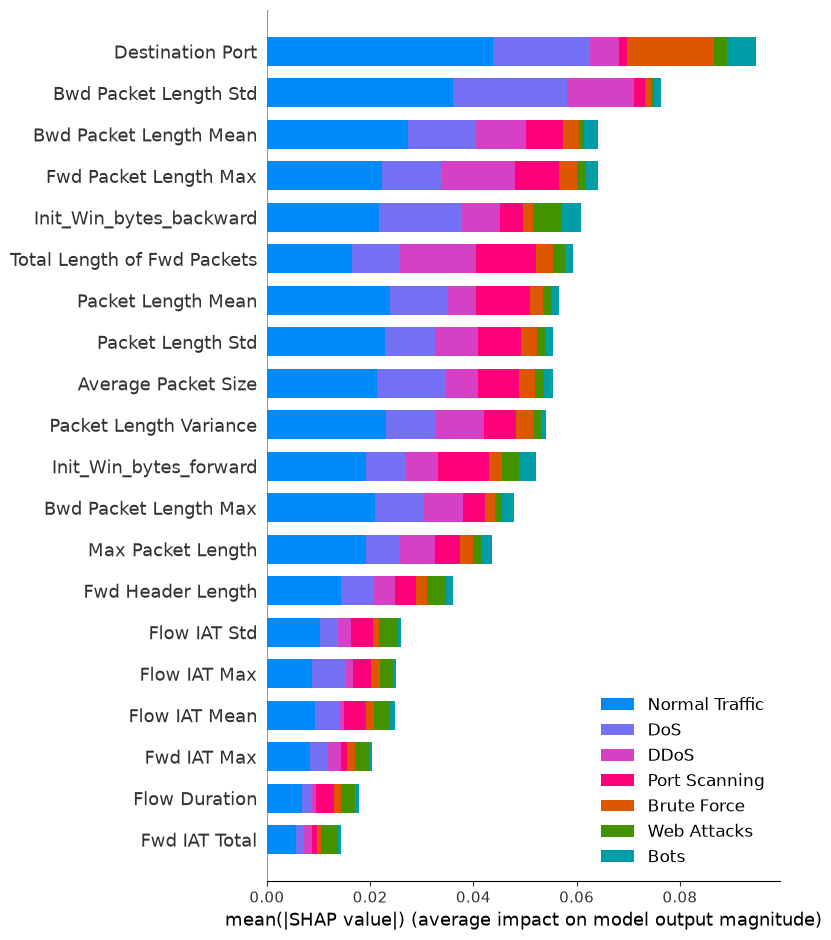

In [22]:
import shap
import matplotlib.pyplot as plt

# Split the 3D array into a list of 7 (samples x features) arrays, one per class
shap_values_list = [shap_values[:, :, i] for i in range(len(class_names))]

# Multiclass bar plot: shows each feature's contribution, broken down by class
shap.summary_plot(shap_values_list, X_shap_sample_named, class_names=class_names, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_bar_multiclass.png", dpi=150)
plt.show()

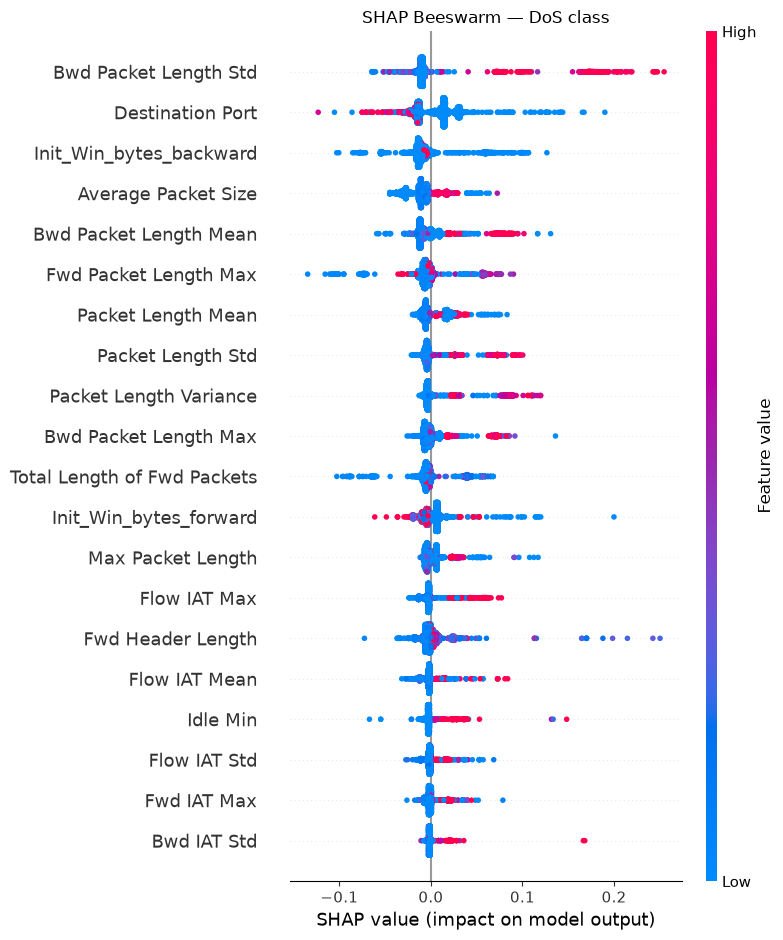

In [23]:
dos_idx = class_names.index("DoS")

shap.summary_plot(shap_values_list[dos_idx], X_shap_sample_named, show=False)
plt.title("SHAP Beeswarm — DoS class")
plt.tight_layout()
plt.savefig("shap_beeswarm_dos.png", dpi=150)
plt.show()

In [24]:
import numpy as np
import pandas as pd

# Predictions + probabilities on the SHAP sample (same row order as shap_values, positional)
y_pred_shap = rf.predict(X_shap_sample_scaled)
y_proba_shap = rf.predict_proba(X_shap_sample_scaled)
y_true_shap = y_shap_sample.reset_index(drop=True)  # reset to align positionally with shap_values' first axis

results_df_shap = pd.DataFrame({
    "true": y_true_shap.values,
    "pred": y_pred_shap
})

sorted_proba = np.sort(y_proba_shap, axis=1)
results_df_shap["margin"] = sorted_proba[:, -1] - sorted_proba[:, -2]  # confidence gap: top prob - runner-up prob

# 1. Correctly classified Normal Traffic
idx_normal_correct = results_df_shap[(results_df_shap.true == "Normal Traffic") & (results_df_shap.pred == "Normal Traffic")].index
# 2. Correctly classified attack traffic — use DoS, your largest attack class
idx_attack_correct = results_df_shap[(results_df_shap.true == "DoS") & (results_df_shap.pred == "DoS")].index
# 3. False positive: true Normal, predicted as an attack
idx_fp = results_df_shap[(results_df_shap.true == "Normal Traffic") & (results_df_shap.pred != "Normal Traffic")].index
# 4. False negative: true attack, predicted as Normal
idx_fn = results_df_shap[(results_df_shap.true != "Normal Traffic") & (results_df_shap.pred == "Normal Traffic")].index
# 5. Difficult multiclass: attack misclassified as a DIFFERENT attack (not involving Normal), sorted by smallest confidence margin
misclassified_attacks = results_df_shap[
    (results_df_shap.true != results_df_shap.pred) &
    (results_df_shap.true != "Normal Traffic") &
    (results_df_shap.pred != "Normal Traffic")
].sort_values("margin")
idx_difficult = misclassified_attacks.index

print("Correct Normal Traffic available:", len(idx_normal_correct))
print("Correct DoS available:", len(idx_attack_correct))
print("False positives (Normal -> Attack):", len(idx_fp))
print("False negatives (Attack -> Normal):", len(idx_fn))
print("Difficult attack<->attack misclassifications:", len(idx_difficult))

Correct Normal Traffic available: 2492
Correct DoS available: 230
False positives (Normal -> Attack): 0
False negatives (Attack -> Normal): 37
Difficult attack<->attack misclassifications: 1


In [28]:
# Select one representative index for each Section-37 case
# Prefer high-confidence correct predictions and low-margin errors

# 1. Correct Normal Traffic — highest confidence margin among correct Normals
idx_normal = results_df_shap.loc[idx_normal_correct].sort_values("margin", ascending=False).index[0]

# 2. Correct DoS — highest confidence margin among correct DoS
idx_dos = results_df_shap.loc[idx_attack_correct].sort_values("margin", ascending=False).index[0]

# 3. False positive — none available (record this)
idx_fp = None   # will be handled gracefully below

# 4. False negative — lowest margin among the 37 FNs (most “borderline” miss)
idx_fn = results_df_shap.loc[idx_fn].sort_values("margin").index[0]

# 5. Difficult attack↔attack — only one exists, take it
idx_difficult = idx_difficult[0]

print("Selected indices:")
print(f"  Correct Normal Traffic : {idx_normal}  (true={results_df_shap.loc[idx_normal, 'true']}, pred={results_df_shap.loc[idx_normal, 'pred']}, margin={results_df_shap.loc[idx_normal, 'margin']:.4f})")
print(f"  Correct DoS            : {idx_dos}  (true={results_df_shap.loc[idx_dos, 'true']}, pred={results_df_shap.loc[idx_dos, 'pred']}, margin={results_df_shap.loc[idx_dos, 'margin']:.4f})")
print(f"  False positive         : none available in sample")
print(f"  False negative         : {idx_fn}  (true={results_df_shap.loc[idx_fn, 'true']}, pred={results_df_shap.loc[idx_fn, 'pred']}, margin={results_df_shap.loc[idx_fn, 'margin']:.4f})")
print(f"  Difficult misclass     : {idx_difficult}  (true={results_df_shap.loc[idx_difficult, 'true']}, pred={results_df_shap.loc[idx_difficult, 'pred']}, margin={results_df_shap.loc[idx_difficult, 'margin']:.4f})")

Selected indices:
  Correct Normal Traffic : 2491  (true=Normal Traffic, pred=Normal Traffic, margin=1.0000)
  Correct DoS            : 2492  (true=DoS, pred=DoS, margin=1.0000)
  False positive         : none available in sample
  False negative         : 3377  (true=Bots, pred=Normal Traffic, margin=0.0008)
  Difficult misclass     : 3240  (true=Web Attacks, pred=DoS, margin=0.8200)


<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

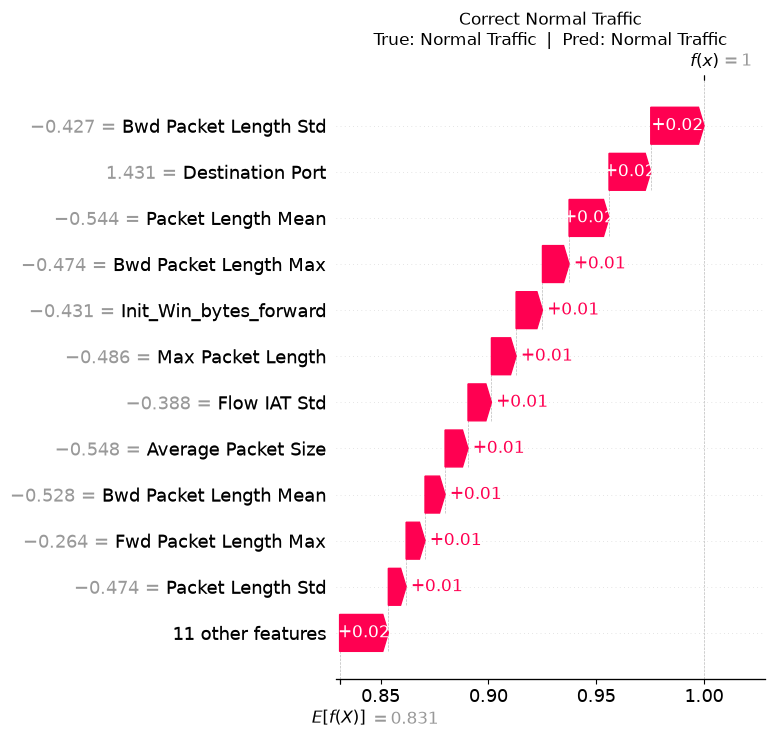

Saved shap_waterfall_correct_normal.png


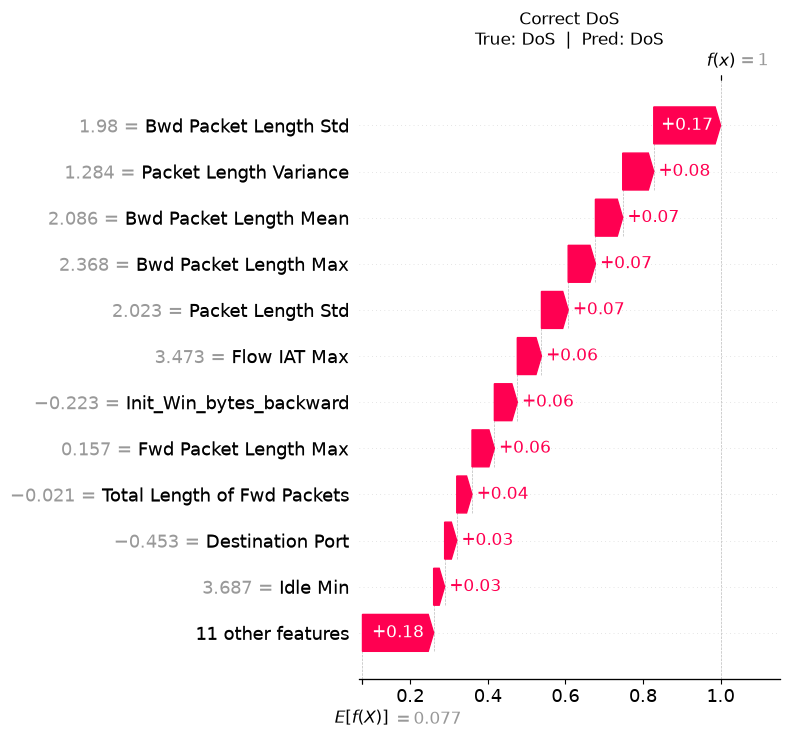

Saved shap_waterfall_correct_dos.png

False positive: none available in the 3 474-sample.
→ Report note: 'No false-positive instance existed in the stratified SHAP sample, consistent with the Random Forest’s near-perfect specificity on this dataset.'


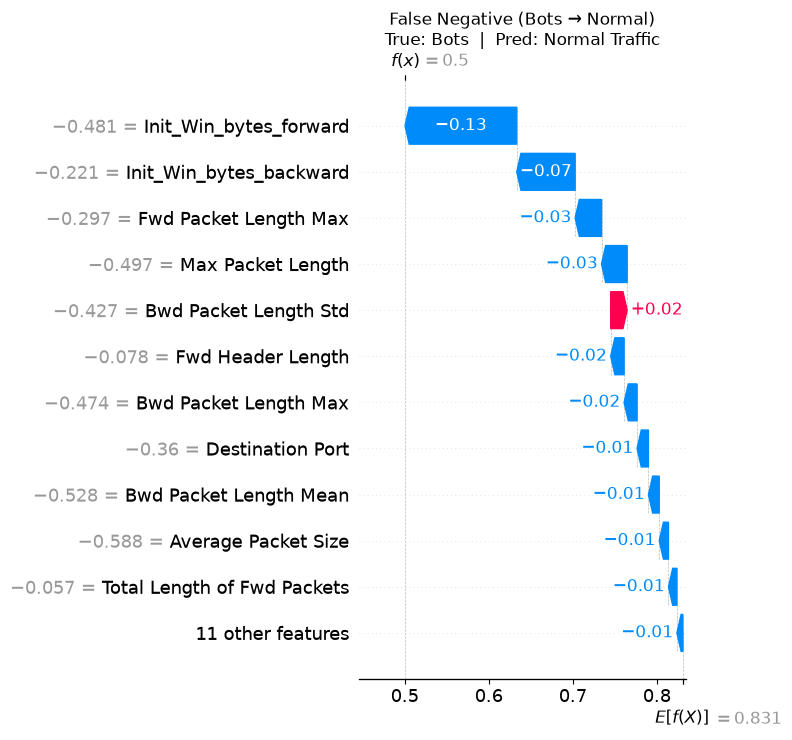

Saved shap_waterfall_fn_bots.png


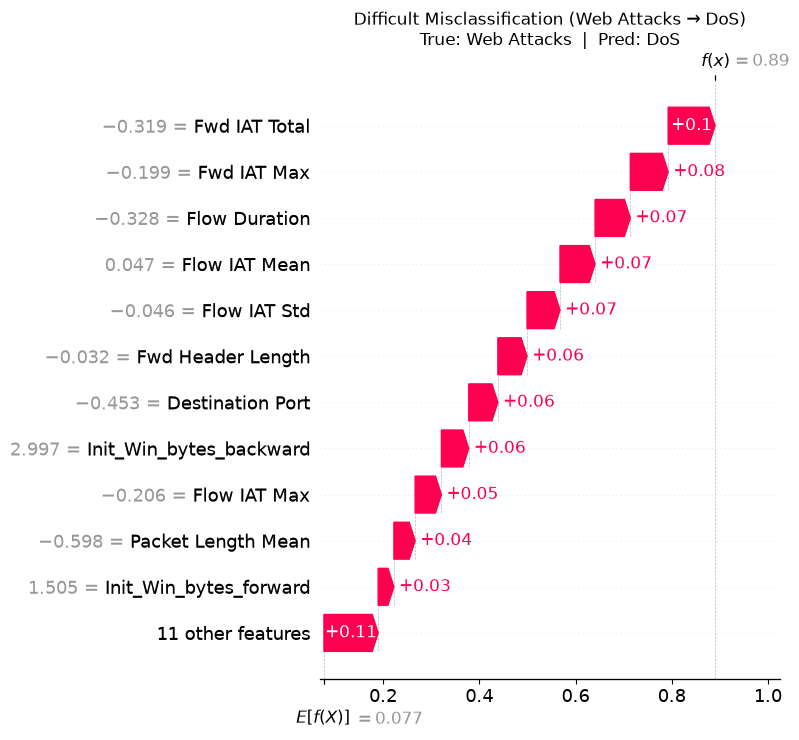

Saved shap_waterfall_difficult_web_dos.png


In [29]:
import shap
import matplotlib.pyplot as plt
import numpy as np

class_names = list(rf.classes_)

def plot_waterfall(sample_idx, title_suffix, filename):
    """Generate and save a SHAP waterfall for one sample."""
    # For multiclass TreeExplainer the expected_value is a list/array of length n_classes
    # We explain the *predicted* class for that sample
    pred_class = results_df_shap.loc[sample_idx, "pred"]
    true_class = results_df_shap.loc[sample_idx, "true"]
    class_idx  = class_names.index(pred_class)

    # shap_values is (n_samples, n_features, n_classes)
    sv = shap_values[sample_idx, :, class_idx]
    base = explainer.expected_value[class_idx] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

    # Build Explanation object for waterfall
    explanation = shap.Explanation(
        values=sv,
        base_values=base,
        data=X_shap_sample_named.iloc[sample_idx].values,
        feature_names=list(majority_features)
    )

    plt.figure()
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f"{title_suffix}\nTrue: {true_class}  |  Pred: {pred_class}")
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")

# 1. Correct Normal Traffic
plot_waterfall(2491, "Correct Normal Traffic", "shap_waterfall_correct_normal.png")

# 2. Correct DoS
plot_waterfall(2492, "Correct DoS", "shap_waterfall_correct_dos.png")

# 3. False positive — none available
print("\nFalse positive: none available in the 3 474-sample.")
print("→ Report note: 'No false-positive instance existed in the stratified SHAP sample, "
      "consistent with the Random Forest’s near-perfect specificity on this dataset.'")

# 4. False negative (Bots → Normal Traffic)
plot_waterfall(3377, "False Negative (Bots → Normal)", "shap_waterfall_fn_bots.png")

# 5. Difficult attack↔attack (Web Attacks → DoS)
plot_waterfall(3240, "Difficult Misclassification (Web Attacks → DoS)", "shap_waterfall_difficult_web_dos.png")

In [30]:
import time
import json
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# ---------- Safety checks ----------
assert 'majority_features' in dir() or os.path.exists("majority_vote_features.csv"), \
       "majority_features not found — load it first"
if 'majority_features' not in dir():
    majority_features = list(pd.read_csv("majority_vote_features.csv")["Feature"])

# You need the full cleaned feature matrix and labels in memory.
# If they are not already present, load them here (adjust path if needed)
# X = ...   # full cleaned features (DataFrame)
# y = ...   # full cleaned labels (Series)

seeds = [42, 52, 62, 72, 82]
models_to_run = {
    "Random Forest": RandomForestClassifier(random_state=None, n_jobs=-1),  # seed set inside loop
    "Extra Trees":   ExtraTreesClassifier(random_state=None, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=None)
}

os.makedirs("saved_metrics/repeated", exist_ok=True)
all_results = []

for seed in seeds:
    print(f"\n===== SEED {seed} =====")
    
    # 1. Stratified split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X[majority_features], y,
        test_size=0.20, stratify=y, random_state=seed
    )
    
    # 2. Scale (fit on train only)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)
    
    seed_results = []
    
    for name, base_model in models_to_run.items():
        print(f"  Training {name} ...", end=" ", flush=True)
        
        # set seed for reproducibility of the model itself
        model = base_model.__class__(**{**base_model.get_params(), "random_state": seed})
        if hasattr(model, "n_jobs"):
            model.n_jobs = -1
        
        t0 = time.time()
        model.fit(X_tr_sc, y_tr)
        train_t = time.time() - t0
        
        t0 = time.time()
        y_pred = model.predict(X_te_sc)
        inf_t = time.time() - t0
        
        metrics = {
            "Seed": seed,
            "Model": name,
            "N_Features": len(majority_features),
            "Accuracy": accuracy_score(y_te, y_pred),
            "F1_macro": f1_score(y_te, y_pred, average="macro", zero_division=0),
            "F1_weighted": f1_score(y_te, y_pred, average="weighted", zero_division=0),
            "Precision_macro": precision_score(y_te, y_pred, average="macro", zero_division=0),
            "Recall_macro": recall_score(y_te, y_pred, average="macro", zero_division=0),
            "Train_Time_s": train_t,
            "Inference_Time_s": inf_t
        }
        
        # save immediately
        fname = f"saved_metrics/repeated/{name.replace(' ', '_')}_seed{seed}.json"
        with open(fname, "w") as f:
            json.dump(metrics, f, indent=2)
        
        seed_results.append(metrics)
        all_results.append(metrics)
        print(f"F1-macro={metrics['F1_macro']:.4f}  ({train_t:.1f}s)")
    
    # also save a per-seed CSV for convenience
    pd.DataFrame(seed_results).to_csv(f"saved_metrics/repeated/seed_{seed}.csv", index=False)

# Final combined table
results_df = pd.DataFrame(all_results)
results_df.to_csv("results_df_repeated_experiments.csv", index=False)
print("\n===== ALL DONE =====")
print(results_df.groupby("Model")[["F1_macro", "Train_Time_s"]].agg(["mean", "std"]).round(4))


===== SEED 42 =====
  Training Random Forest ... F1-macro=0.9659  (320.9s)
  Training Extra Trees ... F1-macro=0.9635  (150.6s)
  Training Decision Tree ... F1-macro=0.9637  (104.3s)

===== SEED 52 =====
  Training Random Forest ... F1-macro=0.9740  (352.2s)
  Training Extra Trees ... F1-macro=0.9701  (141.5s)
  Training Decision Tree ... F1-macro=0.9635  (108.5s)

===== SEED 62 =====
  Training Random Forest ... F1-macro=0.9729  (311.7s)
  Training Extra Trees ... F1-macro=0.9690  (138.5s)
  Training Decision Tree ... F1-macro=0.9658  (141.1s)

===== SEED 72 =====
  Training Random Forest ... F1-macro=0.9682  (322.4s)
  Training Extra Trees ... F1-macro=0.9667  (163.2s)
  Training Decision Tree ... F1-macro=0.9610  (144.3s)

===== SEED 82 =====
  Training Random Forest ... F1-macro=0.9687  (316.5s)
  Training Extra Trees ... F1-macro=0.9655  (143.4s)
  Training Decision Tree ... F1-macro=0.9604  (103.9s)

===== ALL DONE =====
              F1_macro         Train_Time_s         
     

In [31]:
import os
print("Repeated results:", os.path.exists("results_df_repeated_experiments.csv"))
print("Majority features:", os.path.exists("majority_vote_features.csv"))
print("RF model:", os.path.exists("saved_models/RandomForest_majority_vote.joblib"))

Repeated results: True
Majority features: True
RF model: True


In [32]:
import os
shap_figs = [
    "shap_bar_multiclass.png",
    "shap_beeswarm_dos.png",
    "shap_waterfall_correct_normal.png",
    "shap_waterfall_correct_dos.png",
    "shap_waterfall_fn_bots.png",
    "shap_waterfall_difficult_web_dos.png"
]
for f in shap_figs:
    print(f, "→", os.path.exists(f))

shap_bar_multiclass.png → True
shap_beeswarm_dos.png → True
shap_waterfall_correct_normal.png → True
shap_waterfall_correct_dos.png → True
shap_waterfall_fn_bots.png → True
shap_waterfall_difficult_web_dos.png → True


In [4]:
# Cell 1 – imports
%pip install statsmodels
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 1.9 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/11.3 MB 2.1 MB/s eta 0:00:05
   ------ --------------------------------- 1.8/11.3 MB 2.6 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/11.3 MB 2.6 MB/s eta 0:00:04
   ---------- ----------------------------- 2.9/11.3 MB 2.6 MB/s eta 0:00:04
   ------------ --------------------------- 3.7/11.3 MB 2.6 MB/s eta 0:00:03
   --------------- ------------------------ 4.5/11.3 MB 2.7 MB/s eta 0:00:03
   -------------------- ------------------- 5.8/11.3 MB 3.2 MB/s eta 0:00:02
   ------------------------ --------------- 6.8/11.3 MB 3.4 MB/s eta 0:00:02
   ------------------------

In [5]:
majority_features = list(pd.read_csv("majority_vote_features.csv")["Feature"])
import joblib
rf = joblib.load("saved_models/RandomForest_majority_vote.joblib")

In [6]:
# Cell 1 – imports
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

In [7]:
df = pd.read_csv("results_df_repeated_experiments.csv")

In [8]:
from scipy.stats import wilcoxon
import pandas as pd
import numpy as np

# Load the repeated results
df = pd.read_csv("results_df_repeated_experiments.csv")

# Pivot so each model is a column, rows = seeds
pivot = df.pivot(index="Seed", columns="Model", values="F1_macro")
print("Paired Macro-F1 values:")
print(pivot.round(4))
print()

# Pairwise Wilcoxon signed-rank tests
pairs = [
    ("Random Forest", "Extra Trees"),
    ("Random Forest", "Decision Tree"),
    ("Extra Trees", "Decision Tree")
]

print("Wilcoxon signed-rank tests (two-sided):")
results = []
for a, b in pairs:
    stat, p = wilcoxon(pivot[a], pivot[b])
    results.append({"Model_A": a, "Model_B": b, "Statistic": stat, "p_value": p})
    print(f"  {a} vs {b}:  statistic={stat:.1f},  p={p:.4f}")

# Holm correction for multiple comparisons
pvals = [r["p_value"] for r in results]
from statsmodels.stats.multitest import multipletests
reject, p_adj, _, _ = multipletests(pvals, method="holm")

print("\nAfter Holm correction:")
for r, p_a, rej in zip(results, p_adj, reject):
    sig = "significant" if rej else "not significant"
    print(f"  {r['Model_A']} vs {r['Model_B']}: adjusted p={p_a:.4f} → {sig}")

Paired Macro-F1 values:
Model  Decision Tree  Extra Trees  Random Forest
Seed                                            
42            0.9637       0.9635         0.9659
52            0.9635       0.9701         0.9740
62            0.9658       0.9690         0.9729
72            0.9610       0.9667         0.9682
82            0.9604       0.9655         0.9687

Wilcoxon signed-rank tests (two-sided):
  Random Forest vs Extra Trees:  statistic=0.0,  p=0.0625
  Random Forest vs Decision Tree:  statistic=0.0,  p=0.0625
  Extra Trees vs Decision Tree:  statistic=1.0,  p=0.1250

After Holm correction:
  Random Forest vs Extra Trees: adjusted p=0.1875 → not significant
  Random Forest vs Decision Tree: adjusted p=0.1875 → not significant
  Extra Trees vs Decision Tree: adjusted p=0.1875 → not significant
